# 🚗 Car Position and Velocity Estimation using Data Assimilation

In this problem, we simulate the motion of a car in one dimension. The state of the system consists of two variables:

- **Position** \([m]\)
- **Velocity** \([m/s]\)

The system evolves in time according to a simple kinematic model, assuming constant velocity. However, only **noisy position observations** are available at discrete time steps.

The goal is to use different data assimilation methods (e.g., Nudging, Kalman Filter, Ensemble Kalman Filter) to estimate the true position and velocity of the car more accurately by combining:

- A **model prediction** of the system's behavior, and  
- **Partial and noisy observations** (only the position)

This setup allows us to compare the effectiveness of various assimilation methods in filtering out noise and reconstructing unobserved state variables (like velocity) from incomplete data.


## Car Position Estimation with Nudging

In [19]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [20]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})


In [21]:
# Parameters
dt = 0.1
T = 10
steps = int(T / dt)
time = np.linspace(0, T, steps)

# True state [position, velocity]
v_true = 1.5
x_true = np.zeros((steps, 2))
x_true[0] = [0, v_true]

for k in range(1, steps):
    x_true[k, 0] = x_true[k-1, 0] + dt * x_true[k-1, 1]
    x_true[k, 1] = x_true[k-1, 1]

print(steps)

100


In [22]:
# Noisy position observations
pos_noise_std = 1.0
y_obs = x_true[:, 0] + np.random.normal(0, pos_noise_std, size=steps)

In [23]:
# Initial guess with wrong initial condition
x_model = np.zeros((steps, 2))
x_model[0] = [2.0, 1.0]

for k in range(1, steps):
    x_model[k, 0] = x_model[k-1, 0] + dt * x_model[k-1, 1]
    x_model[k, 1] = x_model[k-1, 1]

In [24]:
# Apply simple nudging
alpha = 0.2
x_adjusted = np.zeros_like(x_model)
x_adjusted[0] = x_model[0]

for k in range(1, steps):
    dx = x_adjusted[k-1, 1] + alpha * (y_obs[k-1] - x_adjusted[k-1, 0])
    x_adjusted[k, 0] = x_adjusted[k-1, 0] + dt * dx
    x_adjusted[k, 1] = x_adjusted[k-1, 1]

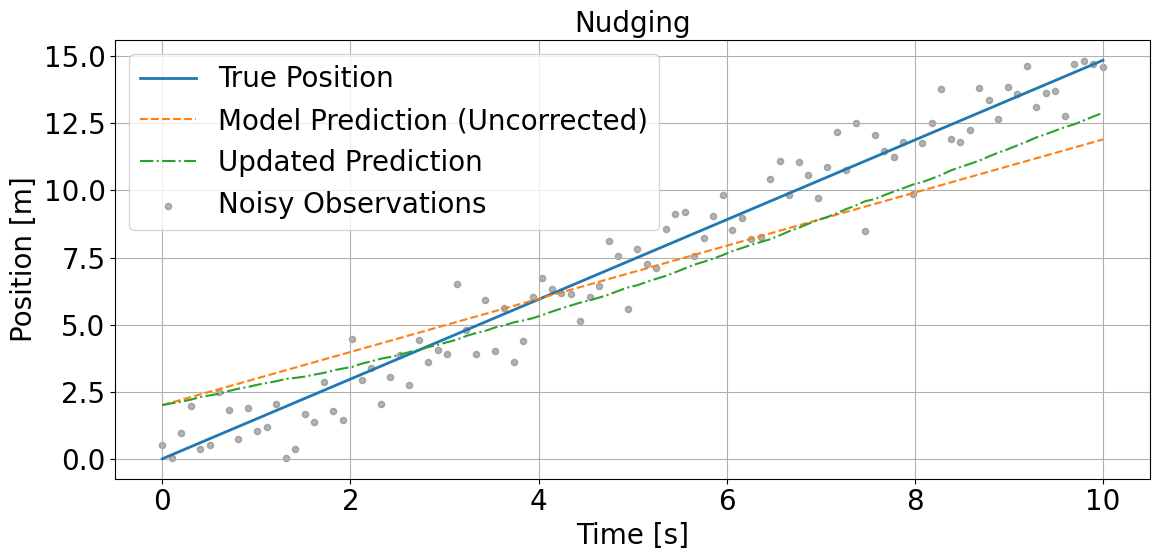

In [25]:

plt.rcParams.update({
    'font.size': 20,              # Tamaño base del texto
    'axes.titlesize': 20,         # Título del gráfico
    'axes.labelsize': 20,         # Ejes X e Y
    'legend.fontsize': 20,        # Leyenda
    'xtick.labelsize': 20,        # Ticks en eje X
    'ytick.labelsize': 20         # Ticks en eje Y
})

# Plot with all components (Nudging)
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time, x_adjusted[:, 0], label='Updated Prediction', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)

plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Nudging')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Car Position Estimation with Kalman Filter

In [26]:
# Kalman Filter parameters
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.array([[0.01, 0], [0, 0.01]])  # model noise
R = np.array([[pos_noise_std**2]])   # observation noise
I = np.eye(2)

# Initial estimates
x_kf = np.zeros((steps, 2))
x_kf[0] = [2.0, 1.0]
P = np.eye(2)

for k in range(1, steps):
    # Predict
    x_pred = F @ x_kf[k-1]
    P_pred = F @ P @ F.T + Q

    # Update
    y = y_obs[k] - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_kf[k] = x_pred + K @ y
    P = (I - K @ H) @ P_pred

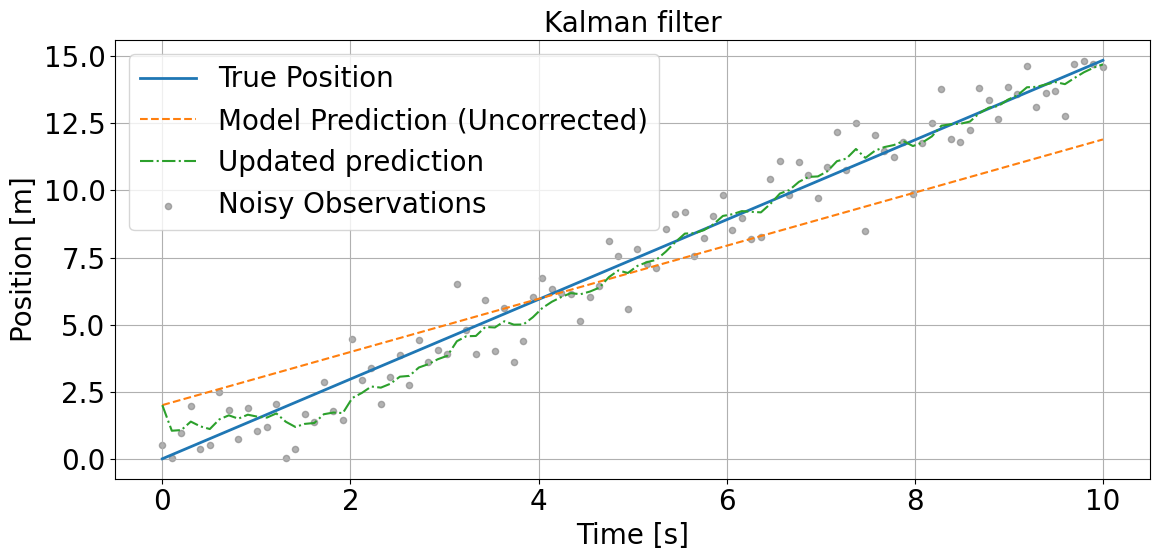

In [27]:
# Plot with all components
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time, x_kf[:, 0], label='Updated prediction', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Kalman filter')
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()

## Car Position Estimation with Ensamble Kalman Filter

In [28]:
# Parámetros del ensemble
N = 50  # número de miembros del ensemble

# Inicialización del ensemble
x_ens = np.zeros((steps, N, 2))  # [tiempo, miembro, estado]
x_ens[0, :, 0] = 2.0 + np.random.normal(0, 1.0, N)  # posición inicial
x_ens[0, :, 1] = 1.0 + np.random.normal(0, 0.5, N)  # velocidad inicial

# Matrices del modelo
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
R = np.array([[pos_noise_std**2]])

# Evolución del EnKF
x_enkf_mean = np.zeros((steps, 2))  # media del ensemble (estimación)
x_enkf_mean[0] = np.mean(x_ens[0], axis=0)

for k in range(1, steps):
    # Predicción de cada miembro
    for i in range(N):
        noise = np.random.multivariate_normal([0, 0], Q)
        x_ens[k, i] = F @ x_ens[k-1, i] + noise

    # Calcular estadísticos del ensemble
    x_mean = np.mean(x_ens[k], axis=0)
    X_prime = x_ens[k] - x_mean  # perturbaciones
    P_f = (X_prime.T @ X_prime) / (N - 1)

    # Perturbar observación
    y_perturbed = y_obs[k] + np.random.normal(0, pos_noise_std, N)

    # Actualización de cada miembro
    for i in range(N):
        Hx = H @ x_ens[k, i]
        S = H @ P_f @ H.T + R
        K = P_f @ H.T @ np.linalg.inv(S)
        innovation = y_perturbed[i] - Hx
        x_ens[k, i] += (K @ innovation).flatten()

    x_enkf_mean[k] = np.mean(x_ens[k], axis=0)


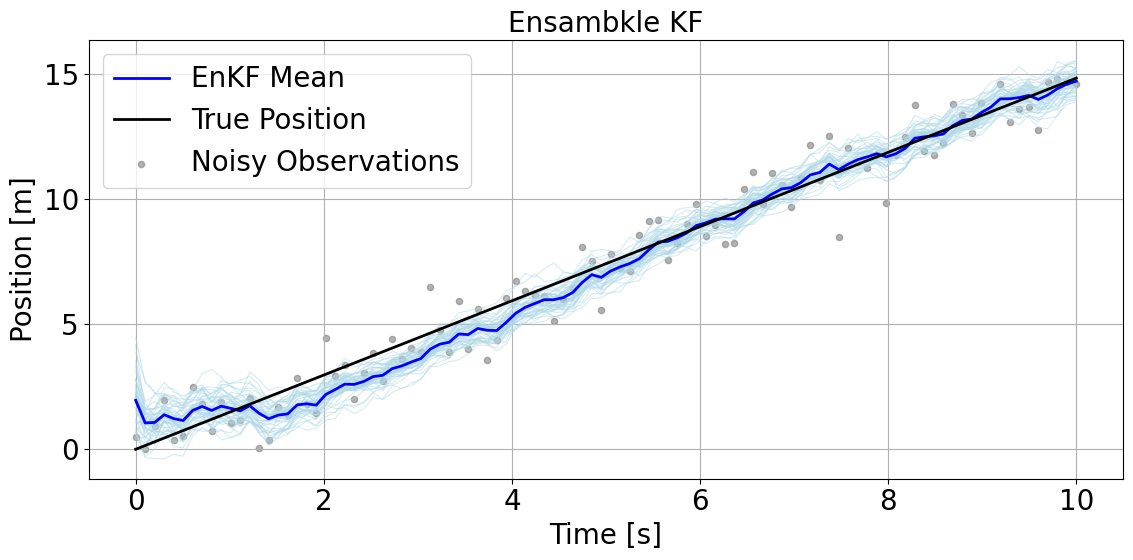

In [29]:
plt.figure(figsize=(12, 6))

# Dibujar cada miembro del ensemble
for i in range(N):
    plt.plot(time, x_ens[:, i, 0], color='lightblue', linewidth=0.8, alpha=0.5)

# Dibujar la media del ensemble
plt.plot(time, x_enkf_mean[:, 0], label='EnKF Mean', color='blue', linewidth=2)

# Dibujar la posición real y observaciones
plt.plot(time, x_true[:, 0], label='True Position', color='black', linewidth=2)
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)

plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('Ensambkle KF')
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


## 3D-Var

In [30]:
# Supuestos iniciales
B = np.diag([1.0, 1.0])  # Background covariance
R = np.array([[pos_noise_std**2]])  # Observation error covariance
H = np.array([[1, 0]])  # Observa solo la posición

# Estado de fondo (background) sin corrección
x_b = x_model.copy()

# Matriz de ganancia variacional (constante en este caso lineal)
HBHT_R_inv = np.linalg.inv(H @ B @ H.T + R)
K_3dvar = B @ H.T @ HBHT_R_inv

# Corrección 3D-Var en cada instante (independiente)
x_3dvar = np.zeros_like(x_b)
for k in range(steps):
    innovation = y_obs[k] - (H @ x_b[k])
    x_3dvar[k] = x_b[k] + (K_3dvar @ innovation).flatten()


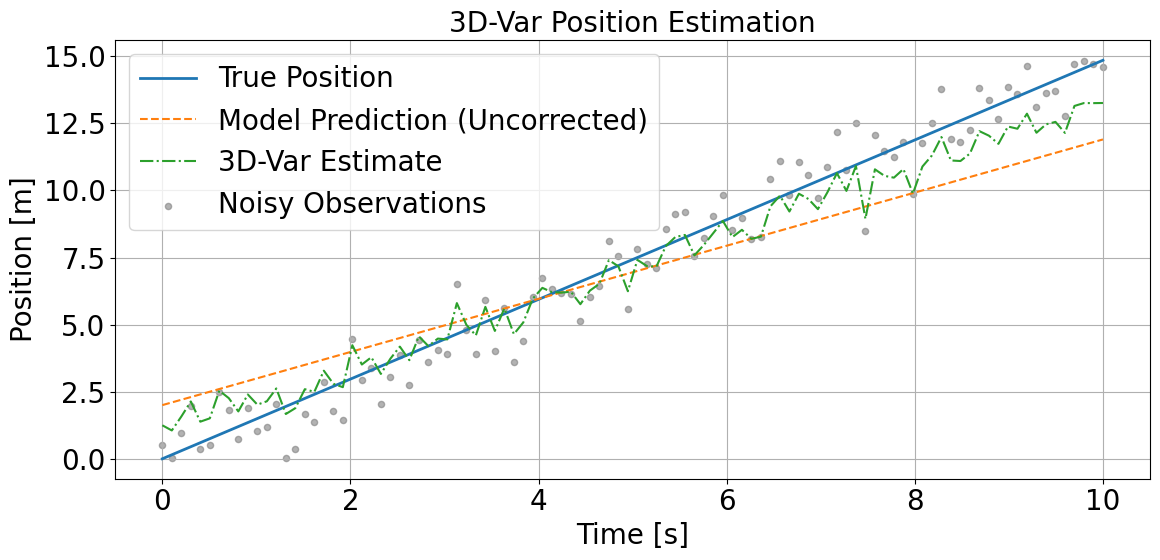

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time, x_3dvar[:, 0], label='3D-Var Estimate', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('3D-Var Position Estimation')
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


## 4D-Var

In [32]:
from scipy.optimize import minimize

# Parámetros
B = np.diag([1.0, 1.0])   # Background covariance
R = np.array([[pos_noise_std**2]])
H = np.array([[1, 0]])

# Modelo lineal
def model_propagate(x0, steps, F):
    traj = np.zeros((steps, 2))
    traj[0] = x0
    for k in range(1, steps):
        traj[k] = F @ traj[k-1]
    return traj

# Cost function parametrizada por la ventana
def J(x0, window):
    x0 = np.array(x0)
    traj = model_propagate(x0, window, F)
    innov = y_obs[:window] - traj[:, 0]
    obs_term = np.sum((innov**2) / R[0, 0])
    back_term = (x0 - x_model[0]).T @ np.linalg.inv(B) @ (x0 - x_model[0])
    return 0.5 * (obs_term + back_term)

# Longitud de la ventana deseada
window = 50  # por ejemplo, 3 segundos si dt = 0.1

# Minimización con la ventana seleccionada
res = minimize(J, x0=np.array([2.0, 1.0]), args=(window,), method='L-BFGS-B')
x0_opt = res.x

# Evolución del estado óptimo hasta el final (o solo la ventana)
x_4dvar = model_propagate(x0_opt, steps, F)


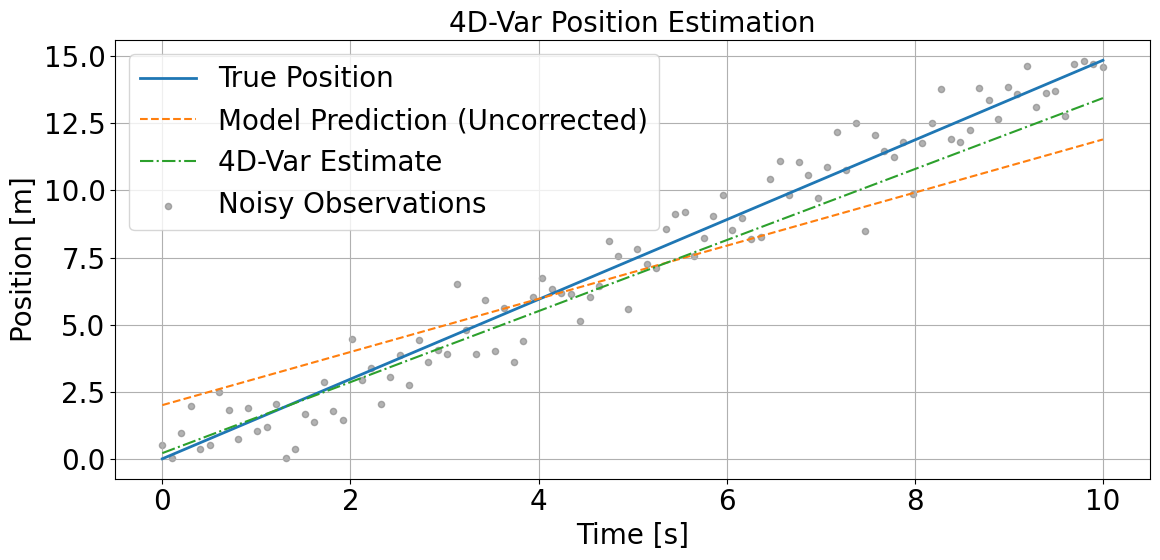

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(time, x_true[:, 0], label='True Position', linewidth=2)
plt.plot(time, x_model[:, 0], label='Model Prediction (Uncorrected)', linestyle='--')
plt.plot(time, x_4dvar[:, 0], label='4D-Var Estimate', linestyle='-.')
plt.scatter(time, y_obs, label='Noisy Observations', color='gray', s=20, alpha=0.6)
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('4D-Var Position Estimation')
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()
